# LWCNN — Training + Full Evaluation

Paper-inspired Lightweight CNN for drone audio detection.
Identical pipeline to original training notebook, with added:
- Computational cost analysis
- Temperature scaling (before/after)
- Confusion matrices at multiple thresholds
- Joint threshold sweep
- Thesis-quality figures saved to Drive

In [1]:
# =============================================================================
# LWCNN — PAPER-STYLE LIGHTWEIGHT DRONE DETECTION CNN
# =============================================================================
!pip -q install datasets librosa numpy scikit-learn tensorflow pandas scipy matplotlib

import os, glob, zipfile, requests, time
import numpy as np
import pandas as pd
import librosa
import scipy.optimize
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import tensorflow as tf
from tensorflow.keras import layers, Model, mixed_precision
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from datasets import load_dataset

In [2]:
# GPU optimisation
mixed_precision.set_global_policy('mixed_float16')
tf.config.optimizer.set_jit(True)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
print('TF:', tf.__version__, '| Policy:', mixed_precision.global_policy())

TF: 2.20.0 | Policy: <DTypePolicy "mixed_float16">


In [3]:
from google.colab import drive
drive.mount('/content/drive')

SEED = 42
rng  = np.random.default_rng(SEED)
tf.random.set_seed(SEED)

WIN_S             = 0.5
HOP_S             = 0.25
MAX_WINDOWS_PER_CLIP = 10
SR_TARGET         = 16000
N_MELS            = 64
N_FFT             = 512
HOP_LENGTH        = 128
FMAX              = 8000
TOP_DB            = 80
TRAIN_FRAC        = 0.8
VAL_FRAC          = 0.1
TEST_FRAC         = 0.1

OUT_DIR    = '/content/drive/MyDrive/drone_audio_processed'
os.makedirs(OUT_DIR, exist_ok=True)
OUT_PATH   = os.path.join(OUT_DIR, f'waveform_{WIN_S:.2f}s_hop{HOP_S:.2f}s_recordsplit.npz')
MODEL_PATH = os.path.join(OUT_DIR, 'model_lwcnn_drone_binary.keras')
FIG_DIR    = os.path.join(OUT_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

AUG_PROB      = 0.7
SNR_MIN       = -5.0
SNR_MAX       = 20.0
MAX_MEL_SHIFT = 3
MAX_EQ_TILT   = 0.10
FREQ_MASK_MAX = 8
TIME_MASK_MAX = 8

BATCH    = 64
EPOCHS   = 30
AUTOTUNE = tf.data.AUTOTUNE

DEMAND_DIR         = '/content/DEMAND'
DEMAND_ZENODO_BASE = 'https://zenodo.org/records/1227121/files'
DEMAND_16K_ENVS    = ['DKITCHEN','DLIVING','DWASHING','NFIELD','NPARK','NRIVER',
                       'OHALLWAY','OMEETING','OOFFICE','PCAFETER','PRESTO','PSTATION',
                       'SPSQUARE','STRAFFIC','TBUS','TCAR','TMETRO']
MAX_NOISE_CLIPS = None

THRESHOLDS = np.round(np.arange(0.05, 0.96, 0.05), 2)
CMAP = LinearSegmentedColormap.from_list('thesis_blue', ['#FFFFFF', '#2E74B5'], N=256)
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10})
print('Config loaded.')

Mounted at /content/drive
Config loaded.


In [4]:
# Feature extraction helpers
def log_mel_db(y, sr):
    y   = np.asarray(y, dtype=np.float32)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT,
                                          hop_length=HOP_LENGTH, fmax=FMAX, power=2.0)
    return librosa.power_to_db(mel, ref=1.0, top_db=TOP_DB).astype(np.float32)

def windows_all(y, sr, win_s, hop_s, rng_local):
    y   = np.asarray(y, dtype=np.float32)
    win = int(round(win_s * sr))
    hop = int(round(hop_s * sr))
    if len(y) <= win:
        out   = np.zeros(win, dtype=np.float32)
        start = rng_local.integers(0, win - len(y) + 1)
        out[start:start + len(y)] = y
        return [out]
    return [y[s:s + win] for s in range(0, len(y) - win + 1, hop)]

def sample_windows(windows, k, rng_local):
    if k is None or len(windows) <= k: return windows
    return [windows[i] for i in rng_local.choice(len(windows), size=k, replace=False)]

def stratified_recording_split(indices, labels, train_frac, val_frac, test_frac, rng_local):
    idx0 = indices[labels[indices] == 0]; idx1 = indices[labels[indices] == 1]
    rng_local.shuffle(idx0); rng_local.shuffle(idx1)
    def split(arr):
        n = len(arr); n_tr = int(round(train_frac*n)); n_va = int(round(val_frac*n))
        return arr[:n_tr], arr[n_tr:n_tr+n_va], arr[n_tr+n_va:]
    tr0,va0,te0 = split(idx0); tr1,va1,te1 = split(idx1)
    train = np.concatenate([tr0,tr1]); rng_local.shuffle(train)
    val   = np.concatenate([va0,va1]); rng_local.shuffle(val)
    test  = np.concatenate([te0,te1]); rng_local.shuffle(test)
    return train, val, test

def build_wave_windows(ds, rec_indices, rng_local):
    subset = ds.select(rec_indices.tolist())
    X_wav, y_out = [], []
    for i, s in enumerate(subset):
        if i % 5000 == 0: print(f'  {i}/{len(rec_indices)}')
        label = int(s['label'])
        y = np.asarray(s['audio']['array'], dtype=np.float32)
        sr = int(s['audio']['sampling_rate'])
        if sr != SR_TARGET: y = librosa.resample(y, orig_sr=sr, target_sr=SR_TARGET)
        wins = sample_windows(windows_all(y, SR_TARGET, WIN_S, HOP_S, rng_local), MAX_WINDOWS_PER_CLIP, rng_local)
        for w in wins: X_wav.append(w); y_out.append(label)
    return np.stack(X_wav).astype(np.float32), np.array(y_out, dtype=np.float32)

def balance_downsample(X, y, rng_local):
    idx0 = np.where(y==0)[0]; idx1 = np.where(y==1)[0]
    n_min = min(len(idx0), len(idx1))
    keep  = np.concatenate([rng_local.choice(idx0,n_min,replace=False),
                             rng_local.choice(idx1,n_min,replace=False)])
    rng_local.shuffle(keep)
    return X[keep], y[keep]

def mel_to_model_array(mel):
    mel  = mel[..., None].astype(np.float32)
    mean = np.mean(mel); std = np.std(mel)
    return ((mel - mean) / (std + 1e-6)).astype(np.float32)

def rms(x):
    return np.sqrt(np.mean(np.asarray(x, dtype=np.float32)**2) + 1e-12)

def add_real_noise_snr(y, noise_bank, snr_db, rng_local):
    y     = np.asarray(y, dtype=np.float32)
    nb    = noise_bank[rng_local.integers(0, len(noise_bank))]
    n     = len(y)
    if len(nb) >= n:
        s   = rng_local.integers(0, len(nb)-n+1)
        nb  = nb[s:s+n]
    else:
        nb  = np.tile(nb, int(np.ceil(n/len(nb))))[:n]
    noise_scaled = nb * (rms(y) / (10**(snr_db/20.0)) / (rms(nb) + 1e-12))
    y_noisy = y + noise_scaled
    peak = np.max(np.abs(y_noisy))
    return (y_noisy / peak).astype(np.float32) if peak > 1.0 else y_noisy

def drone_metrics(y_true, y_prob, t):
    pred = (y_prob >= t).astype(int)
    cm   = confusion_matrix(y_true, pred, labels=[0,1])
    tp=cm[1,1]; fp=cm[0,1]; fn=cm[1,0]
    prec=tp/(tp+fp+1e-9); rec=tp/(tp+fn+1e-9)
    return prec, rec, 2*prec*rec/(prec+rec+1e-9)

def plot_cm(cm, title, ax):
    thresh = cm.max()/2.0
    im = ax.imshow(cm, cmap=CMAP, vmin=0, vmax=cm.max(), interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.06).set_label('Count', fontsize=8)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['No Drone','Drone'], fontsize=9)
    ax.set_yticklabels(['No Drone','Drone'], fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9, labelpad=8)
    ax.set_ylabel('Actual', fontsize=9, labelpad=18)
    ax.set_title(title, fontsize=9, fontweight='normal', pad=10)
    for row in range(2):
        rt = cm[row].sum()
        for col in range(2):
            count = cm[row,col]; pct = count/rt*100 if rt>0 else 0
            color = 'white' if count>thresh else '#1a1a1a'
            ax.text(col, row-0.12, [['TN','FP'],['FN','TP']][row][col],
                    ha='center', va='center', fontsize=11, fontweight='bold', color=color)
            ax.text(col, row+0.12, f'{count:,}\n({pct:.1f}%)',
                    ha='center', va='center', fontsize=9, color=color)

def save_fig(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=200, bbox_inches='tight', facecolor='white')
    print(f'Saved: {path}')

print('Helpers defined.')

Helpers defined.


In [5]:
# Load dataset
print('Loading dataset...')
ds     = load_dataset('geronimobasso/drone-audio-detection-samples', split='train')
labels = np.array(ds['label'], dtype=np.int64)
sr_used = SR_TARGET
_tmp    = np.zeros(int(round(WIN_S * sr_used)), dtype=np.float32)
N_FRAMES    = log_mel_db(_tmp, sr_used).shape[1]
INPUT_SHAPE = (N_MELS, N_FRAMES, 1)
print(f'Input shape: {INPUT_SHAPE}')

Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

...

data/train-00036-of-00039.parquet:   0%|          | 0.00/75.0M [00:00<?, ?B/s]

data/train-00037-of-00039.parquet:   0%|          | 0.00/74.9M [00:00<?, ?B/s]

data/train-00038-of-00039.parquet:   0%|          | 0.00/75.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/180320 [00:00<?, ? examples/s]

Input shape: (64, 63, 1)


In [6]:
# Download DEMAND noise bank
if not os.path.exists(DEMAND_DIR) or not glob.glob(os.path.join(DEMAND_DIR,'**','*.wav'),recursive=True):
    os.makedirs(DEMAND_DIR, exist_ok=True)
    for env in DEMAND_16K_ENVS:
        url      = f'{DEMAND_ZENODO_BASE}/{env}_16k.zip?download=1'
        zip_path = f'/content/demand_{env.lower()}.zip'
        print(f'  {env}...', end=' ', flush=True)
        for attempt in range(3):
            try:
                r = requests.get(url, stream=True, timeout=120); r.raise_for_status(); break
            except Exception as e:
                print(f'retry {attempt+1}...', end=' ')
                time.sleep(5)
        with open(zip_path,'wb') as f:
            for chunk in r.iter_content(1024*1024): f.write(chunk)
        with zipfile.ZipFile(zip_path) as z: z.extractall(DEMAND_DIR)
        os.remove(zip_path); print('done')

noise_bank = []; seg_n = int(3.0 * sr_used)
for p in glob.glob(os.path.join(DEMAND_DIR,'**','*.wav'),recursive=True):
    try:
        y, fs = librosa.load(p, sr=None, mono=True)
        if fs != sr_used: y = librosa.resample(y, orig_sr=fs, target_sr=sr_used)
        for s in range(0, len(y)-seg_n+1, seg_n):
            seg = y[s:s+seg_n].astype(np.float32)
            if np.max(np.abs(seg)) > 1e-4: noise_bank.append(seg)
    except: pass
print(f'Noise bank: {len(noise_bank)} segments')

  DKITCHEN... done
  DLIVING... done
  DWASHING... done
  NFIELD... done
  NPARK... done
  NRIVER... done
  OHALLWAY... done
  OMEETING... done
  OOFFICE... done
  PCAFETER... done
  PRESTO... done
  PSTATION... done
  SPSQUARE... done
  STRAFFIC... done
  TBUS... done
  TCAR... done
  TMETRO... done
Noise bank: 27200 segments


In [7]:
# Recording-level split + waveform extraction
all_idx = np.arange(len(ds), dtype=np.int64)
train_rec, val_rec, test_rec = stratified_recording_split(all_idx, labels, TRAIN_FRAC, VAL_FRAC, TEST_FRAC, rng)

if os.path.exists(OUT_PATH):
    print(f'Loading cached NPZ: {OUT_PATH}')
    _c = np.load(OUT_PATH)
    X_train_wav=_c['X_train_wav']; y_train_wav=_c['y_train_wav']
    X_val_wav=_c['X_val_wav'];     y_val_wav=_c['y_val_wav']
    X_test_wav=_c['X_test_wav'];   y_test_wav=_c['y_test_wav']
    print(f'  train={X_train_wav.shape}, val={X_val_wav.shape}, test={X_test_wav.shape}')
else:
    print('Extracting waveform windows...')
    X_train_wav, y_train_wav = build_wave_windows(ds, train_rec, rng)
    X_val_wav,   y_val_wav   = build_wave_windows(ds, val_rec,   rng)
    X_test_wav,  y_test_wav  = build_wave_windows(ds, test_rec,  rng)
    X_train_wav, y_train_wav = balance_downsample(X_train_wav, y_train_wav, rng)
    np.savez_compressed(OUT_PATH,
        X_train_wav=X_train_wav, y_train_wav=y_train_wav,
        X_val_wav=X_val_wav,     y_val_wav=y_val_wav,
        X_test_wav=X_test_wav,   y_test_wav=y_test_wav,
        sr=sr_used, win_s=WIN_S, hop_s=HOP_S)
    print(f'Cached: {OUT_PATH}')

Loading cached NPZ: /content/drive/MyDrive/drone_audio_processed/waveform_0.50s_hop0.25s_recordsplit.npz
  train=(255488, 8000), val=(32731, 8000), test=(32694, 8000)


In [8]:
# tf.data augmentation pipeline
def tf_logmel_from_wave(wave):
    def _py(w):
        return log_mel_db(w.numpy().astype(np.float32), sr_used)
    mel = tf.py_function(_py, inp=[wave], Tout=tf.float32)
    mel.set_shape([N_MELS, N_FRAMES])
    return mel

def augment_wave_with_noise(wave, label):
    def add_noise():
        snr = tf.random.uniform([], SNR_MIN, SNR_MAX, dtype=tf.float32)
        def _py(w, snr_db):
            return add_real_noise_snr(w.numpy().astype(np.float32), noise_bank, float(snr_db),
                                       np.random.default_rng()).astype(np.float32)
        w_n = tf.py_function(_py, inp=[wave, snr], Tout=tf.float32)
        w_n.set_shape(wave.shape)
        return w_n, label
    return tf.cond(tf.random.uniform([]) < AUG_PROB, add_noise, lambda: (wave, label))

def apply_spec_augment(mel):
    f  = tf.random.uniform([], 0, FREQ_MASK_MAX+1, dtype=tf.int32)
    f0 = tf.random.uniform([], 0, tf.maximum(1, N_MELS-f+1), dtype=tf.int32)
    mask_f = tf.concat([tf.ones((f0,N_FRAMES,1),mel.dtype),
                         tf.zeros((f,N_FRAMES,1),mel.dtype),
                         tf.ones((N_MELS-f0-f,N_FRAMES,1),mel.dtype)], axis=0)
    mel = mel * mask_f
    t  = tf.random.uniform([], 0, TIME_MASK_MAX+1, dtype=tf.int32)
    t0 = tf.random.uniform([], 0, tf.maximum(1, N_FRAMES-t+1), dtype=tf.int32)
    mask_t = tf.concat([tf.ones((N_MELS,t0,1),mel.dtype),
                         tf.zeros((N_MELS,t,1),mel.dtype),
                         tf.ones((N_MELS,N_FRAMES-t0-t,1),mel.dtype)], axis=1)
    return mel * mask_t

def normalise_mel(mel):
    mean = tf.reduce_mean(mel); std = tf.math.reduce_std(mel)
    return (mel - mean) / (std + 1e-6)

def wave_to_model_input_train(wave, label):
    wave, label = augment_wave_with_noise(wave, label)
    mel = tf_logmel_from_wave(wave)
    mel = mel[..., tf.newaxis]
    mel = apply_spec_augment(mel)
    mel = normalise_mel(mel)
    return tf.cast(mel, tf.float32), tf.cast(label, tf.float32)

def wave_to_model_input_eval(wave, label):
    wave, label = augment_wave_with_noise(wave, label)
    mel = tf_logmel_from_wave(wave)
    mel = mel[..., tf.newaxis]
    mel = normalise_mel(mel)
    return tf.cast(mel, tf.float32), tf.cast(label, tf.float32)

train_ds = (tf.data.Dataset.from_tensor_slices((X_train_wav, y_train_wav))
            .shuffle(len(X_train_wav), seed=SEED)
            .map(wave_to_model_input_train, num_parallel_calls=AUTOTUNE)
            .batch(BATCH).prefetch(AUTOTUNE))
val_ds   = (tf.data.Dataset.from_tensor_slices((X_val_wav, y_val_wav))
            .map(wave_to_model_input_eval, num_parallel_calls=AUTOTUNE)
            .batch(BATCH).prefetch(AUTOTUNE))
test_ds  = (tf.data.Dataset.from_tensor_slices((X_test_wav, y_test_wav))
            .map(wave_to_model_input_eval, num_parallel_calls=AUTOTUNE)
            .batch(BATCH).prefetch(AUTOTUNE))
print('tf.data pipelines ready.')

tf.data pipelines ready.


In [9]:
# LWCNN model definition (paper-style)
def conv_bn_relu(x, filters, kernel_size, strides=1, name=None):
    x = layers.Conv2D(filters, kernel_size, strides=strides, padding='same',
                      use_bias=False, kernel_initializer='he_normal',
                      name=None if name is None else f'{name}_conv')(x)
    x = layers.BatchNormalization(name=None if name is None else f'{name}_bn')(x)
    x = layers.ReLU(name=None if name is None else f'{name}_relu')(x)
    return x

def conv_bn(x, filters, kernel_size, strides=1, name=None):
    x = layers.Conv2D(filters, kernel_size, strides=strides, padding='same',
                      use_bias=False, kernel_initializer='he_normal',
                      name=None if name is None else f'{name}_conv')(x)
    x = layers.BatchNormalization(name=None if name is None else f'{name}_bn')(x)
    return x

def dw_bn(x, kernel_size=3, strides=1, name=None):
    x = layers.DepthwiseConv2D(kernel_size, strides=strides, padding='same',
                                use_bias=False, depthwise_initializer='he_normal',
                                name=None if name is None else f'{name}_dw')(x)
    x = layers.BatchNormalization(name=None if name is None else f'{name}_bn')(x)
    return x

def branch_left_down(x, filters, name=None):
    y = dw_bn(x, 3, strides=2, name=None if name is None else f'{name}_dw')
    y = conv_bn(y, filters, 1, name=None if name is None else f'{name}_pw')
    return layers.ReLU(name=None if name is None else f'{name}_relu')(y)

def branch_right_down(x, filters, name=None):
    y = conv_bn_relu(x, filters, 1, name=None if name is None else f'{name}_pw1')
    y = dw_bn(y, 3, strides=2, name=None if name is None else f'{name}_dw')
    y = conv_bn(y, filters, 1, name=None if name is None else f'{name}_pw2')
    return layers.ReLU(name=None if name is None else f'{name}_relu')(y)

def branch_right_nodown(x, filters, name=None):
    y = conv_bn_relu(x, filters, 1, name=None if name is None else f'{name}_pw1')
    y = dw_bn(y, 3, name=None if name is None else f'{name}_dw')
    y = conv_bn(y, filters, 1, name=None if name is None else f'{name}_pw2')
    return layers.ReLU(name=None if name is None else f'{name}_relu')(y)

def lwcnn_drone_binary(input_shape, dropout_rate=0.30):
    inp = layers.Input(shape=input_shape, name='input_mel')
    x   = conv_bn_relu(inp, 64, 3, name='stem')
    x   = layers.MaxPooling2D((2,2), strides=2, padding='same', name='stem_pool')(x)
    left  = branch_left_down(x, 64, name='block1_left')
    right = branch_right_down(x, 64, name='block1_right')
    x = layers.Concatenate(name='block1_concat')([left, right])
    x = layers.DepthwiseConv2D(1, padding='same', use_bias=False,
                                name='block1_shuffle_dw')(x)
    x = layers.BatchNormalization(name='block1_shuffle_bn')(x)
    c = x.shape[-1] // 2
    x1 = layers.Lambda(lambda t: t[:,:,:,:c], name='split_x1')(x)
    x2 = layers.Lambda(lambda t: t[:,:,:,c:], name='split_x2')(x)
    r2 = branch_right_nodown(x2, c, name='block2_right')
    x  = layers.Concatenate(name='block2_concat')([x1, r2])
    x  = layers.DepthwiseConv2D(1, padding='same', use_bias=False,
                                 name='block2_shuffle_dw')(x)
    x  = layers.BatchNormalization(name='block2_shuffle_bn')(x)
    x  = layers.GlobalAveragePooling2D(name='gap')(x)
    x  = layers.Dropout(dropout_rate, name='dropout')(x)
    x  = layers.Dense(256, activation='relu', dtype='float32', name='fc1')(x)
    logits = layers.Dense(1, activation=None, dtype='float32', name='logits')(x)
    return Model(inp, logits, name='lwcnn_drone_binary')

model = lwcnn_drone_binary(INPUT_SHAPE)
model.summary()
print(f'Parameters: {model.count_params():,}')

Model: "lwcnn_drone_binary"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_mel           │ (None, 64, 63, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 63,    │        576 │ input_mel[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 63,    │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu (ReLU)    │ (None, 64, 63,    │          0 │ stem_bn[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_pool           │ (None, 32, 32,    │          0 │ stem_relu[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_right_pw1_c… │ (None, 32, 32,    │      4,096 │ stem_pool[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_right_pw1_bn │ (None, 32, 32,    │        256 │ block1_right_pw1… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_right_pw1_r… │ (None, 32, 32,    │          0 │ block1_right_pw1… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_left_dw_dw   │ (None, 16, 16,    │        576 │ stem_pool[0][0]   │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_right_dw_dw  │ (None, 16, 16,    │        576 │ block1_right_pw1… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_left_dw_bn   │ (None, 16, 16,    │        256 │ block1_left_dw_d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_right_dw_bn  │ (None, 16, 16,    │        256 │ block1_right_dw_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_left_pw_conv │ (None, 16, 16,    │      4,096 │ block1_left_dw_b… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_right_pw2_c… │ (None, 16, 16,    │      4,096 │ block1_right_dw_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_left_pw_bn   │ (None, 16, 16,    │        256 │ block1_left_pw_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_right_pw2_bn │ (None, 16, 16,    │        256 │ block1_right_pw2… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_left_relu    │ (None, 16, 16,    │          0 │ block1_left_pw_b

 Total params: 59,649 (233.00 KB)

 Trainable params: 57,985 (226.50 KB)

 Non-trainable params: 1,664 (6.50 KB)

Parameters: 59,649


In [ ]:
# Compile and train
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy', threshold=0.0),
        tf.keras.metrics.AUC(name='auc', from_logits=True),
        tf.keras.metrics.Precision(name='precision', thresholds=0.0),
        tf.keras.metrics.Recall(name='recall', thresholds=0.0),
    ]
)
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(MODEL_PATH, monitor='val_auc', mode='max',
                                        save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                      patience=6, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max',
                                          factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=1)

Epoch 1/30
3992/3992 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.9517 - auc: 0.9818 - loss: 0.1518 - precision: 0.9570 - recall: 0.9442
Epoch 1: val_auc improved from None to 0.99666, saving model to /content/drive/MyDrive/drone_audio_processed/model_lwcnn_drone_binary.keras

Epoch 1: finished saving model to /content/drive/MyDrive/drone_audio_processed/model_lwcnn_drone_binary.keras
3992/3992 ━━━━━━━━━━━━━━━━━━━━ 1139s 271ms/step - accuracy: 0.9735 - auc: 0.9922 - loss: 0.0895 - precision: 0.9832 - recall: 0.9635 - val_accuracy: 0.9863 - val_auc: 0.9967 - val_loss: 0.0496 - val_precision: 0.9878 - val_recall: 0.9853 - learning_rate: 1.0000e-04
Epoch 2/30
3992/3992 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.9844 - auc: 0.9957 - loss: 0.0552 - precision: 0.9941 - recall: 0.9745
Epoch 2: val_auc improved from 0.99666 to 0.99714, saving model to /content/drive/MyDrive/drone_audio_processed/model_lwcnn_drone_binary.keras

Epoch 2: finished saving model to /content/drive/MyDrive/

Saved: /content/drive/MyDrive/drone_audio_processed/figures/lwcnn_training_curves.png


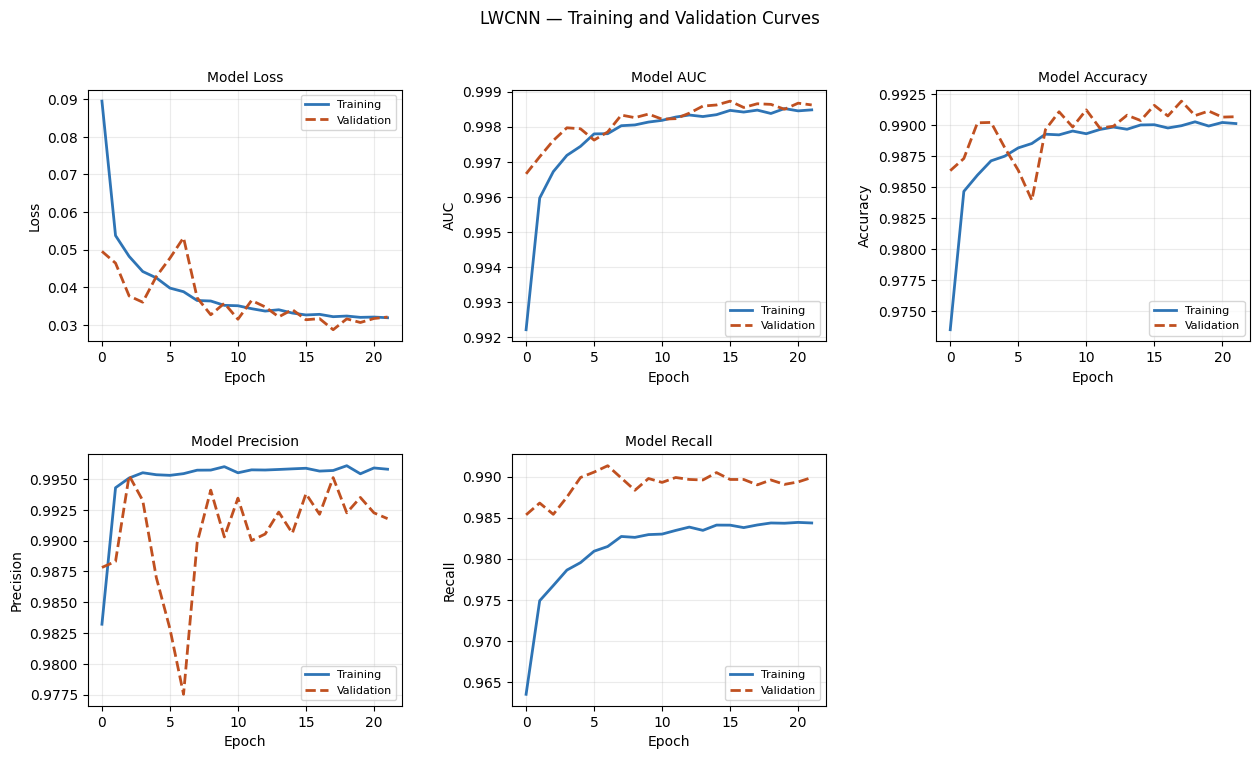

In [ ]:
# Training curves
h = history.history
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.subplots_adjust(hspace=0.45, wspace=0.35)
panels = [('loss','Loss'),('auc','AUC'),('accuracy','Accuracy'),
          ('precision','Precision'),('recall','Recall')]
for ax, (m, title) in zip(axes.flat, panels):
    ax.plot(h[m], color='#2E74B5', lw=2, label='Training')
    ax.plot(h[f'val_{m}'], color='#C05020', lw=2, ls='--', label='Validation')
    ax.set_title(f'Model {title}', fontsize=10)
    ax.set_xlabel('Epoch'); ax.set_ylabel(title)
    ax.legend(fontsize=8); ax.grid(alpha=0.25)
axes.flat[-1].set_visible(False)
fig.suptitle('LWCNN — Training and Validation Curves', fontsize=12)
save_fig(fig, 'lwcnn_training_curves.png'); plt.show()

In [ ]:
# Computational cost analysis
n_params   = model.count_params()
model_size = os.path.getsize(MODEL_PATH) / (1024*1024)
dummy = np.random.randn(1, N_MELS, N_FRAMES, 1).astype(np.float32)
_ = model.predict(dummy, verbose=0)  # warmup
t0 = time.time()
for _ in range(100): model.predict(dummy, verbose=0)
ms_per_window = (time.time()-t0)/100*1000

print('=== COMPUTATIONAL COSTS ===')
print(f'Total parameters    : {n_params:,}')
print(f'Model size (disk)   : {model_size:.2f} MB')
print(f'Inference/window    : {ms_per_window:.2f} ms')
print(f'Real-time factor    : {ms_per_window/500:.5f}x (0.5s window)')

=== COMPUTATIONAL COSTS ===
Total parameters    : 59,649
Model size (disk)   : 1.30 MB
Inference/window    : 74.85 ms
Real-time factor    : 0.14971x (0.5s window)


In [ ]:
# Internal test set evaluation
y_true_eval = np.concatenate([y.numpy() for x, y in test_ds], axis=0).astype(int)
t0 = time.time()
y_logits    = model.predict(test_ds, verbose=1).ravel()
int_inf_time = time.time() - t0
y_prob      = tf.sigmoid(y_logits).numpy()

int_auc = roc_auc_score(y_true_eval, y_prob)
print(f'ROC-AUC (NOISY internal test): {int_auc:.4f}')
print(f'Inference time ({len(y_true_eval)} windows): {int_inf_time:.1f}s ({int_inf_time/len(y_true_eval)*1000:.3f} ms/window)')

for t_thresh, label in [(0.5, 'threshold=0.5'), (0.3, 'threshold=0.3')]:
    pred = (y_prob >= t_thresh).astype(int)
    print(f'\n=== INTERNAL ({label}) ===')
    print(confusion_matrix(y_true_eval, pred))
    print(classification_report(y_true_eval, pred, digits=4))

511/511 ━━━━━━━━━━━━━━━━━━━━ 124s 235ms/step
ROC-AUC (NOISY internal test): 0.9979
Inference time (32694 windows): 124.1s (3.796 ms/window)

=== INTERNAL (threshold=0.5) ===
[[15715    98]
 [  308 16573]]
              precision    recall  f1-score   support

           0     0.9808    0.9938    0.9872     15813
           1     0.9941    0.9818    0.9879     16881

    accuracy                         0.9876     32694
   macro avg     0.9874    0.9878    0.9876     32694
weighted avg     0.9877    0.9876    0.9876     32694


=== INTERNAL (threshold=0.3) ===
[[15595   218]
 [  242 16639]]
              precision    recall  f1-score   support

           0     0.9847    0.9862    0.9855     15813
           1     0.9871    0.9857    0.9864     16881

    accuracy                         0.9859     32694
   macro avg     0.9859    0.9859    0.9859     32694
weighted avg     0.9859    0.9859    0.9859     32694



In [ ]:
# Temperature scaling — fit on validation set
y_val_true   = np.concatenate([y.numpy() for x,y in val_ds], axis=0).astype(int)
val_logits   = model.predict(val_ds, verbose=0).ravel()

def nll_loss(log_T):
    T     = np.exp(log_T[0])
    probs = 1 / (1 + np.exp(-val_logits / T))
    eps   = 1e-7
    return -np.mean(y_val_true * np.log(probs+eps) + (1-y_val_true) * np.log(1-probs+eps))

result      = scipy.optimize.minimize(nll_loss, x0=[0.0], method='L-BFGS-B')
TEMPERATURE = float(np.exp(result.x[0]))
print(f'Optimal temperature T = {TEMPERATURE:.4f}')

y_prob_cal  = tf.sigmoid(y_logits / TEMPERATURE).numpy()
int_auc_cal = roc_auc_score(y_true_eval, y_prob_cal)
print(f'Internal AUC (uncal): {int_auc:.4f}')
print(f'Internal AUC (cal):   {int_auc_cal:.4f}')
print(f'Prob range (uncal): [{y_prob.min():.3f}, {y_prob.max():.3f}]')
print(f'Prob range (cal):   [{y_prob_cal.min():.3f}, {y_prob_cal.max():.3f}]')

Optimal temperature T = 0.9030
Internal AUC (uncal): 0.9979
Internal AUC (cal):   0.9979
Prob range (uncal): [0.000, 1.000]
Prob range (cal):   [0.000, 1.000]


Saved: /content/drive/MyDrive/drone_audio_processed/figures/lwcnn_internal_cm.png


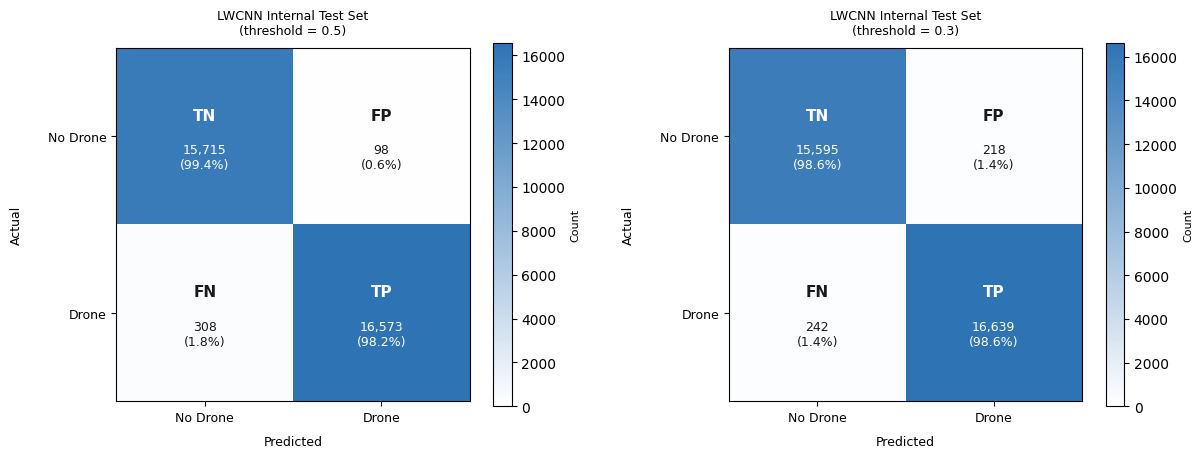

In [ ]:
# Internal confusion matrices figure
fig, axes = plt.subplots(1, 2, figsize=(13, 5)); fig.subplots_adjust(wspace=0.55)
plot_cm(confusion_matrix(y_true_eval, (y_prob>=0.5).astype(int)),
        'LWCNN Internal Test Set\n(threshold = 0.5)', axes[0])
plot_cm(confusion_matrix(y_true_eval, (y_prob>=0.3).astype(int)),
        'LWCNN Internal Test Set\n(threshold = 0.3)', axes[1])
save_fig(fig, 'lwcnn_internal_cm.png'); plt.show()

Saved: /content/drive/MyDrive/drone_audio_processed/figures/lwcnn_internal_roc.png


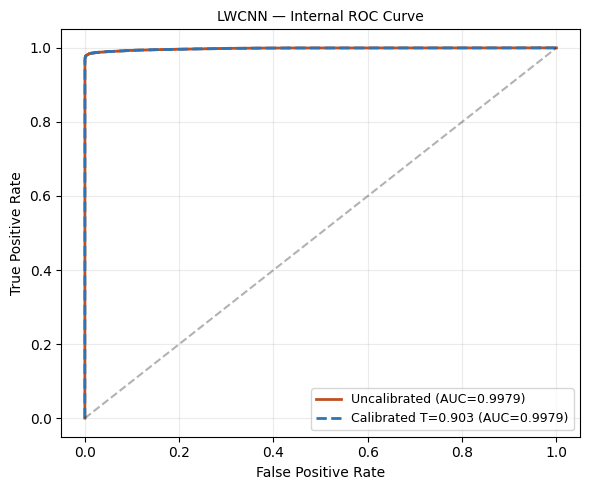

In [ ]:
# Internal ROC curve
fig, ax = plt.subplots(figsize=(6, 5))
fpr_u,tpr_u,_ = roc_curve(y_true_eval, y_prob)
fpr_c,tpr_c,_ = roc_curve(y_true_eval, y_prob_cal)
ax.plot(fpr_u, tpr_u, color='#C05020', lw=2, label=f'Uncalibrated (AUC={int_auc:.4f})')
ax.plot(fpr_c, tpr_c, color='#2E74B5', lw=2, ls='--', label=f'Calibrated T={TEMPERATURE:.3f} (AUC={int_auc_cal:.4f})')
ax.plot([0,1],[0,1],'k--',alpha=0.3)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('LWCNN — Internal ROC Curve', fontsize=10, fontweight='normal')
ax.legend(fontsize=9); ax.grid(alpha=0.25); plt.tight_layout()
save_fig(fig, 'lwcnn_internal_roc.png'); plt.show()

In [ ]:
# External Svanstrom evaluation
EXT_ROOT        = '/content/external_drone_thesis'
os.makedirs(EXT_ROOT, exist_ok=True)
EXT_ZIP_URL     = 'https://codeload.github.com/DroneDetectionThesis/Drone-detection-dataset/zip/refs/heads/master'
EXT_ZIP_PATH    = os.path.join(EXT_ROOT, 'repo.zip')
EXT_EXTRACT_DIR = os.path.join(EXT_ROOT, 'repo')

if not os.path.exists(EXT_ZIP_PATH):
    print('Downloading Svanström dataset...')
    r = requests.get(EXT_ZIP_URL, stream=True); r.raise_for_status()
    with open(EXT_ZIP_PATH,'wb') as f:
        for chunk in r.iter_content(1024*1024): f.write(chunk)
    with zipfile.ZipFile(EXT_ZIP_PATH) as z: z.extractall(EXT_EXTRACT_DIR)

subdirs      = [p for p in glob.glob(os.path.join(EXT_EXTRACT_DIR,'*')) if os.path.isdir(p)]
EXT_REPO_ROOT = subdirs[0]
ext_wavs      = sorted(glob.glob(os.path.join(EXT_REPO_ROOT,'**','*.wav'), recursive=True))
ext_labels    = np.array([1 if 'drone' in os.path.basename(p).lower() else 0 for p in ext_wavs])
print(f'External: {len(ext_wavs)} clips — drone:{ext_labels.sum()}, no-drone:{(ext_labels==0).sum()}')

# Clip-level predictions (max-pool over windows — same as original notebook)
local_rng = np.random.default_rng(SEED)
ext_clip_probs_uncal = []
for p in ext_wavs:
    y, sr = librosa.load(p, sr=None, mono=True)
    if sr != sr_used: y = librosa.resample(y, orig_sr=sr, target_sr=sr_used)
    wins = windows_all(y, sr_used, WIN_S, HOP_S, local_rng)
    X = []
    for w in wins:
        if local_rng.random() < AUG_PROB:
            w = add_real_noise_snr(w, noise_bank, local_rng.uniform(SNR_MIN,SNR_MAX), local_rng)
        X.append(mel_to_model_array(log_mel_db(w, sr_used)))
    if not X: ext_clip_probs_uncal.append(0.0); continue
    logits = model.predict(np.stack(X), batch_size=BATCH, verbose=0).ravel()
    probs  = tf.sigmoid(logits).numpy()
    ext_clip_probs_uncal.append(float(np.max(probs)))  # max-pool

ext_clip_probs_uncal = np.array(ext_clip_probs_uncal)
ext_clip_logits      = np.log(ext_clip_probs_uncal / (1 - ext_clip_probs_uncal + 1e-9) + 1e-9)
ext_clip_probs_cal   = tf.sigmoid(ext_clip_logits / TEMPERATURE).numpy()

ext_auc_uncal = roc_auc_score(ext_labels, ext_clip_probs_uncal)
ext_auc_cal   = roc_auc_score(ext_labels, ext_clip_probs_cal)
print(f'\nExternal clip AUC (uncal): {ext_auc_uncal:.4f}')
print(f'External clip AUC (cal):   {ext_auc_cal:.4f}')

for t_thresh, probs, label in [
    (0.5, ext_clip_probs_uncal, 'UNCAL t=0.5'),
    (0.3, ext_clip_probs_uncal, 'UNCAL t=0.3'),
    (0.5, ext_clip_probs_cal,   'CAL   t=0.5'),
    (0.3, ext_clip_probs_cal,   'CAL   t=0.3')]:
    pred = (probs >= t_thresh).astype(int)
    print(f'\n=== EXTERNAL ({label}) ===')
    print(confusion_matrix(ext_labels, pred))
    print(classification_report(ext_labels, pred, digits=4))

External: 90 clips — drone:30, no-drone:60

External clip AUC (uncal): 0.4983
External clip AUC (cal):   0.4983

=== EXTERNAL (UNCAL t=0.5) ===
[[17 43]
 [ 6 24]]
              precision    recall  f1-score   support

           0     0.7391    0.2833    0.4096        60
           1     0.3582    0.8000    0.4948        30

    accuracy                         0.4556        90
   macro avg     0.5487    0.5417    0.4522        90
weighted avg     0.6122    0.4556    0.4380        90


=== EXTERNAL (UNCAL t=0.3) ===
[[12 48]
 [ 3 27]]
              precision    recall  f1-score   support

           0     0.8000    0.2000    0.3200        60
           1     0.3600    0.9000    0.5143        30

    accuracy                         0.4333        90
   macro avg     0.5800    0.5500    0.4171        90
weighted avg     0.6533    0.4333    0.3848        90


=== EXTERNAL (CAL   t=0.5) ===
[[17 43]
 [ 6 24]]
              precision    recall  f1-score   support

           0     0.7391   

In [ ]:
# Window-level external AUC
local_rng = np.random.default_rng(SEED)
all_win_logits = []; all_win_labels = []
for p, lab in zip(ext_wavs, ext_labels):
    y, sr = librosa.load(p, sr=None, mono=True)
    if sr != sr_used: y = librosa.resample(y, orig_sr=sr, target_sr=sr_used)
    for w in windows_all(y, sr_used, WIN_S, HOP_S, local_rng):
        if local_rng.random() < AUG_PROB:
            w = add_real_noise_snr(w, noise_bank, local_rng.uniform(SNR_MIN,SNR_MAX), local_rng)
        X = mel_to_model_array(log_mel_db(w, sr_used))[None]
        all_win_logits.append(float(model.predict(X, verbose=0).ravel()[0]))
        all_win_labels.append(lab)

win_probs = tf.sigmoid(np.array(all_win_logits)).numpy()
print(f'Window-level external AUC: {roc_auc_score(all_win_labels, win_probs):.4f}  ({len(win_probs)} windows)')

Window-level external AUC: 0.5682  (3510 windows)


In [ ]:
# Threshold sweep
def run_sweep(int_probs, ext_probs, label):
    rows = []
    for t in THRESHOLDS:
        _,_,if1  = drone_metrics(y_true_eval, int_probs, t)
        _,er,ef1 = drone_metrics(ext_labels,  ext_probs, t)
        combined = 2*if1*er/(if1+er+1e-9)
        rows.append(dict(threshold=t, int_f1=round(if1,4), ext_recall=round(er,4),
                         ext_f1=round(ef1,4), combined=round(combined,4)))
    df   = pd.DataFrame(rows)
    best = df.loc[df['combined'].idxmax()]
    print(f'\n=== SWEEP ({label}) ===')
    print(df.to_string(index=False))
    print(f'Optimal t={best["threshold"]}  combined={best["combined"]}  int_f1={best["int_f1"]}  ext_recall={best["ext_recall"]}')
    return df, best

df_uncal, best_uncal = run_sweep(y_prob,     ext_clip_probs_uncal, 'UNCALIBRATED')
df_cal,   best_cal   = run_sweep(y_prob_cal, ext_clip_probs_cal,   f'CALIBRATED T={TEMPERATURE:.4f}')


=== SWEEP (UNCALIBRATED) ===
 threshold  int_f1  ext_recall  ext_f1  combined
      0.05  0.9535      1.0000  0.5085    0.9762
      0.10  0.9717      1.0000  0.5217    0.9857
      0.15  0.9785      0.9667  0.5179    0.9725
      0.20  0.9823      0.9333  0.5138    0.9572
      0.25  0.9847      0.9000  0.5047    0.9405
      0.30  0.9864      0.9000  0.5143    0.9412
      0.35  0.9872      0.9000  0.5143    0.9416
      0.40  0.9876      0.8667  0.5149    0.9232
      0.45  0.9879      0.8000  0.4898    0.8841
      0.50  0.9879      0.8000  0.4948    0.8841
      0.55  0.9879      0.8000  0.5000    0.8841
      0.60  0.9882      0.8000  0.5000    0.8842
      0.65  0.9882      0.8000  0.5000    0.8842
      0.70  0.9883      0.7000  0.4615    0.8195
      0.75  0.9882      0.6667  0.4494    0.7962
      0.80  0.9881      0.6333  0.4368    0.7719
      0.85  0.9877      0.5667  0.4304    0.7202
      0.90  0.9868      0.4000  0.3529    0.5693
      0.95  0.9855      0.3000  0.2903 

Saved: /content/drive/MyDrive/drone_audio_processed/figures/lwcnn_external_cm.png


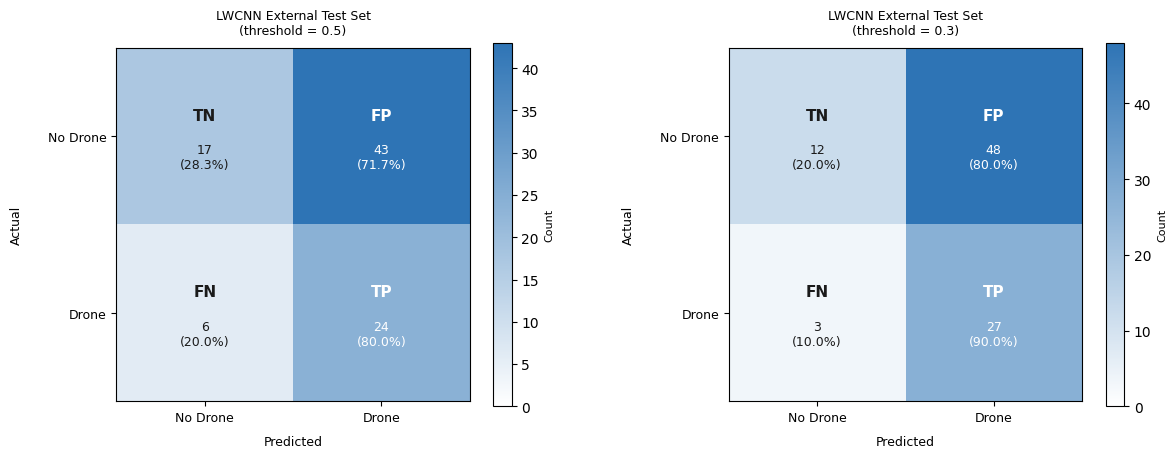

In [ ]:
# External confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5)); fig.subplots_adjust(wspace=0.55)
plot_cm(confusion_matrix(ext_labels, (ext_clip_probs_uncal>=0.5).astype(int)),
        'LWCNN External Test Set\n(threshold = 0.5)', axes[0])
plot_cm(confusion_matrix(ext_labels, (ext_clip_probs_uncal>=0.3).astype(int)),
        'LWCNN External Test Set\n(threshold = 0.3)', axes[1])
save_fig(fig, 'lwcnn_external_cm.png'); plt.show()

Saved: /content/drive/MyDrive/drone_audio_processed/figures/lwcnn_threshold_sweep.png


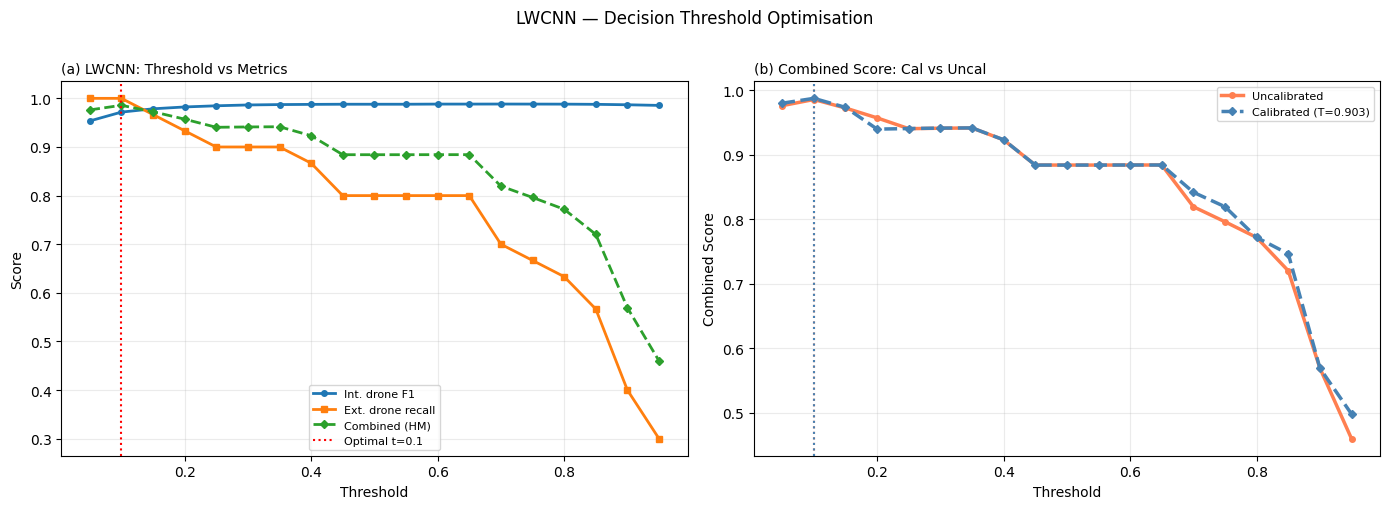

In [ ]:
# Threshold sweep plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(df_uncal['threshold'], df_uncal['int_f1'],     lw=2, marker='o', ms=4, label='Int. drone F1')
ax.plot(df_uncal['threshold'], df_uncal['ext_recall'], lw=2, marker='s', ms=4, label='Ext. drone recall')
ax.plot(df_uncal['threshold'], df_uncal['combined'],   lw=2, ls='--', marker='D', ms=4, label='Combined (HM)')
ax.axvline(float(best_uncal['threshold']), color='red', ls=':', lw=1.5,
           label=f'Optimal t={best_uncal["threshold"]}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('(a) LWCNN: Threshold vs Metrics', fontsize=10, fontweight='normal', loc='left')
ax.legend(fontsize=8); ax.grid(alpha=0.25)
ax = axes[1]
ax.plot(df_uncal['threshold'], df_uncal['combined'], lw=2.5, color='coral',
        marker='o', ms=4, label='Uncalibrated')
ax.plot(df_cal['threshold'],   df_cal['combined'],   lw=2.5, color='steelblue',
        marker='D', ms=4, ls='--', label=f'Calibrated (T={TEMPERATURE:.3f})')
ax.axvline(float(best_uncal['threshold']), color='coral',     ls=':', lw=1.5)
ax.axvline(float(best_cal['threshold']),   color='steelblue', ls=':', lw=1.5)
ax.set_xlabel('Threshold'); ax.set_ylabel('Combined Score')
ax.set_title('(b) Combined Score: Cal vs Uncal', fontsize=10, fontweight='normal', loc='left')
ax.legend(fontsize=8); ax.grid(alpha=0.25)
fig.suptitle('LWCNN — Decision Threshold Optimisation', fontsize=12, y=1.01)
plt.tight_layout()
save_fig(fig, 'lwcnn_threshold_sweep.png'); plt.show()

Saved: /content/drive/MyDrive/drone_audio_processed/figures/lwcnn_temperature_scaling.png


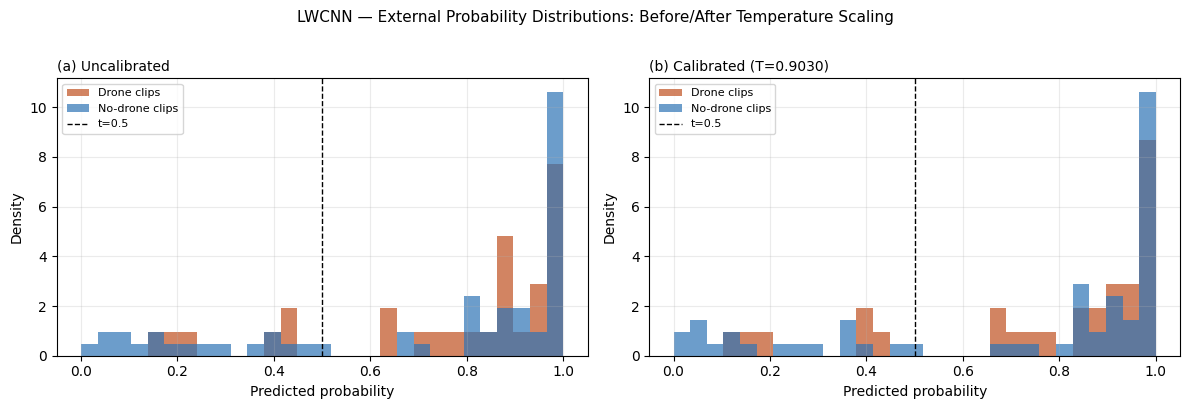

In [ ]:
# Temperature scaling probability distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins = np.linspace(0, 1, 30)
dm = ext_labels==1; ndm = ext_labels==0
for ax, probs, title in [
    (axes[0], ext_clip_probs_uncal, '(a) Uncalibrated'),
    (axes[1], ext_clip_probs_cal,   f'(b) Calibrated (T={TEMPERATURE:.4f})')]:
    ax.hist(probs[dm],  bins=bins, alpha=0.7, color='#C05020', label='Drone clips',    density=True)
    ax.hist(probs[ndm], bins=bins, alpha=0.7, color='#2E74B5', label='No-drone clips', density=True)
    ax.axvline(0.5, color='black', ls='--', lw=1, label='t=0.5')
    ax.set_xlabel('Predicted probability'); ax.set_ylabel('Density')
    ax.set_title(title, fontsize=10, fontweight='normal', loc='left')
    ax.legend(fontsize=8); ax.grid(alpha=0.25)
fig.suptitle('LWCNN — External Probability Distributions: Before/After Temperature Scaling',
             fontsize=11, y=1.01)
plt.tight_layout()
save_fig(fig, 'lwcnn_temperature_scaling.png'); plt.show()

Saved: /content/drive/MyDrive/drone_audio_processed/figures/lwcnn_external_roc.png


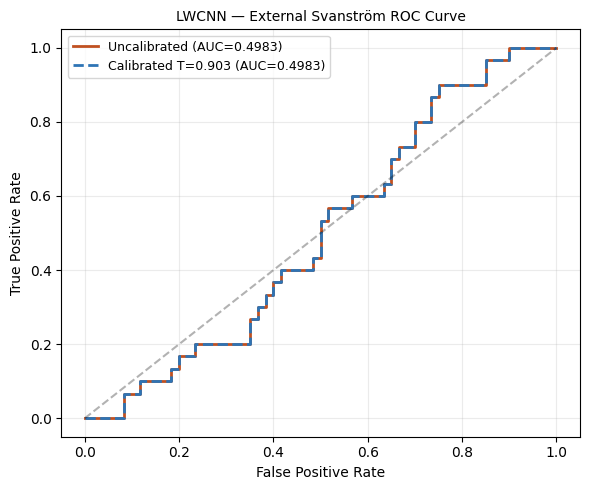

In [ ]:
# External ROC curve
fig, ax = plt.subplots(figsize=(6, 5))
fpr_u,tpr_u,_ = roc_curve(ext_labels, ext_clip_probs_uncal)
fpr_c,tpr_c,_ = roc_curve(ext_labels, ext_clip_probs_cal)
ax.plot(fpr_u, tpr_u, color='#C05020', lw=2, label=f'Uncalibrated (AUC={ext_auc_uncal:.4f})')
ax.plot(fpr_c, tpr_c, color='#2E74B5', lw=2, ls='--', label=f'Calibrated T={TEMPERATURE:.3f} (AUC={ext_auc_cal:.4f})')
ax.plot([0,1],[0,1],'k--',alpha=0.3)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('LWCNN — External Svanström ROC Curve', fontsize=10, fontweight='normal')
ax.legend(fontsize=9); ax.grid(alpha=0.25); plt.tight_layout()
save_fig(fig, 'lwcnn_external_roc.png'); plt.show()

In [ ]:
# Final summary
print('\n' + '='*60)
print('LWCNN — FINAL RESULTS SUMMARY')
print('='*60)
print(f'Parameters         : {n_params:,}')
print(f'Model size         : {model_size:.2f} MB')
print(f'Inference/window   : {ms_per_window:.2f} ms')
print(f'Real-time factor   : {ms_per_window/500:.5f}x')
print(f'Temperature T      : {TEMPERATURE:.4f}')
print()
print(f'Internal AUC (uncal) : {int_auc:.4f}')
print(f'Internal AUC (cal)   : {int_auc_cal:.4f}')
print(f'External AUC (uncal) : {ext_auc_uncal:.4f}')
print(f'External AUC (cal)   : {ext_auc_cal:.4f}')
print()
print(f'Optimal t (uncal)    : {best_uncal["threshold"]}  combined: {best_uncal["combined"]}')
print(f'Optimal t (cal)      : {best_cal["threshold"]}  combined: {best_cal["combined"]}')
print(f'\nAll figures saved to: {FIG_DIR}')


LWCNN — FINAL RESULTS SUMMARY
Parameters         : 59,649
Model size         : 1.30 MB
Inference/window   : 74.85 ms
Real-time factor   : 0.14971x
Temperature T      : 0.9030

Internal AUC (uncal) : 0.9979
Internal AUC (cal)   : 0.9979
External AUC (uncal) : 0.4983
External AUC (cal)   : 0.4983

Optimal t (uncal)    : 0.1  combined: 0.9857
Optimal t (cal)      : 0.1  combined: 0.9875

All figures saved to: /content/drive/MyDrive/drone_audio_processed/figures
